# Final Project – Machine Learning

# Prediction of Student Academic Performance


Nicolás Carrión

# 1. Introduction

The PISA (*Programme for International Student Assessment*) assessment, developed by the Organisation for Economic Co-operation and Development (OECD), is one of the most important international studies for measuring the academic performance of 15-year-old students in key areas such as mathematics, reading, and science. PISA aims to evaluate the extent to which students have acquired the knowledge and skills necessary to participate fully in modern society, focusing not only on the acquisition of knowledge but also on the ability to apply it in real-world situations [1].

In addition to assessing academic performance, PISA collects a large amount of contextual information related to students' socioeconomic, family, school, and personal factors. This information makes it possible to study the influence of various factors on academic achievement, contributing to the identification of patterns that may be useful for designing strategies and policies aimed at improving educational quality.

However, the large number of variables available in the PISA questionnaires presents an analytical challenge due to high dimensionality, the presence of missing values, and potential redundancy among variables. In this context, machine learning techniques provide tools capable of modeling complex relationships and generating accurate predictions from large volumes of data.

In this project, the PISA 2022 dataset will be used with the objective of predicting students' mathematics performance, represented by the `PV_MATH_MEAN` variable, which corresponds to the average of the ten plausible mathematics values. To achieve this, a feature selection process will first be conducted in order to identify the most relevant variables and reduce the dimensionality of the problem. Subsequently, an Exploratory Data Analysis (EDA) will be performed on the selected variables, and two machine learning models will be trained: a Random Forest Regressor and an Artificial Neural Network.

Finally, the performance of both models will be evaluated using regression metrics and compared through statistical tests to determine whether significant differences exist between their predictive capabilities. This work constitutes an initial approach to the study of academic performance through machine learning techniques and may serve as a foundation for future, more extensive research, including the development of thesis projects focused on interpreting factors associated with student achievement.

## 2. Data Ingestion

First, we extract the data from the ZIP file available at https://webfs.oecd.org/pisa2022/SCH_QQQ_SAS.zip. To improve processing efficiency, the dataset is stored in Parquet format. At the same time, we split the data into training and test sets.

In [1]:
import pandas as pd

def sas_to_parquet():
    df = pd.read_sas(
        "data/CY08MSP_STU_QQQ.SAS7BDAT",
        format="sas7bdat"
    )
    print("Loaded SAS file into DataFrame")

    for col in df.select_dtypes(include=[object]).columns:
        df[col] = df[col].apply(lambda x: x.decode("utf-8") if isinstance(x, bytes) else x)

    df.to_parquet("data/pisa2022.parquet", index=False)
    print("Converted SAS file to Parquet format and saved as data/pisa2022.parquet")

In [2]:
sas_to_parquet()

Loaded SAS file into DataFrame
Converted SAS file to Parquet format and saved as data/pisa2022.parquet


In [1]:
import pyarrow.dataset as ds
from sklearn.model_selection import train_test_split

def split_data(test_size=0.2, random_state=42):
    dataset = ds.dataset('data/pisa2022.parquet', format='parquet')
    table = dataset.to_table()
    
    train_table, test_table = train_test_split(
        table.to_pandas(),
        test_size=test_size,
        random_state=random_state
    )

    print(f"Train rows: {len(train_table)} ({(1-test_size)*100:.1f}%)")
    print(f"Test rows: {len(test_table)} ({test_size*100:.1f}%)")

    return train_table, test_table

def save_split(train_df, test_df):
    train_df.to_parquet('data/train.parquet', index=False)
    print("Saved train split to data/train.parquet")

    test_df.to_parquet('data/test.parquet', index=False)
    print("Saved test split to data/test.parquet")

In [2]:
save_split(*split_data())

Train rows: 490995 (80.0%)
Test rows: 122749 (20.0%)
Saved train split to data/train.parquet
Saved test split to data/test.parquet


In [4]:
import pyarrow.parquet as pq

table = pq.read_table("data/pisa2022.parquet")

print("Shape:", table.num_rows, "x", table.num_columns)
print("Estimated memory usage (MB):", table.nbytes / 1024**2)

Shape: 613744 x 1278
Estimated memory usage (MB): 6100.628432273865


Given the size of the dataset, loading all records into memory is not practical. Consequently, the analysis must be conducted either on selected subsets of columns or on a reduced sample of rows (for example, 5% of the data, corresponding to approximately 30k records).

In [5]:
print(f"5% of the data: {table.num_rows * 0.05} rows")

5% of the data: 30687.2 rows


## 3. ETL

Next, we clean the dataset to retain only the features and the target variable, `PV_MATH_MEAN`. Since this variable is not directly available in the original dataset, it must first be computed and added. To reduce redundancy, all other plausible values (including those for mathematics, reading, and science) are removed, keeping only `PV_MATH_MEAN` as the target variable.

In [10]:
import pyarrow.parquet as pq
import pyarrow.compute as pc
import pyarrow as pa

def extract_data():
    train = pq.read_table('data/train.parquet')
    test = pq.read_table('data/test.parquet')
    return {'train': train, 'test': test}

def transform_data(table):
    columns = table.column_names

    math_cols = [f'PV{i}MATH' for i in range(1, 11)]
    available = [c for c in math_cols if c in columns]

    if available:
        arrays = [table[c] for c in available]
        mean_array = arrays[0]
        for arr in arrays[1:]:
            mean_array = pc.add(mean_array, arr)
        mean_array = pc.divide(mean_array, len(available))
        table = table.append_column("PV_MATH_MEAN",mean_array)
        print(f"Transformed {len(available)} PV_MATH columns into PV_MATH_MEAN.")

    pv_cols = [c for c in columns if c.startswith("PV") and c != "PV_MATH_MEAN"]
    print(f"Dropping {len(pv_cols)} PV columns")
    table = table.drop_columns(pv_cols)

    return table

def load_data(table, file_name):
    pq.write_table(table, file_name)
    print(f"Saved transformed data to {file_name}")

In [11]:
for name, table in extract_data().items():
    table = transform_data(table)
    load_data(table, file_name=f"data/{name}_transformed.parquet")

Transformed 10 PV_MATH columns into PV_MATH_MEAN.
Dropping 110 PV columns
Saved transformed data to data/train_transformed.parquet
Transformed 10 PV_MATH columns into PV_MATH_MEAN.
Dropping 110 PV columns
Saved transformed data to data/test_transformed.parquet


## 4. Feature Selection

The original dataset contains more than 1,200 variables; therefore, dimensionality reduction is required before model training. The first step is to encode categorical predictors using either one-hot encoding or frequency encoding, depending on their cardinality and analytical context.

The PISA 2022 codebook is available at https://webfs.oecd.org/pisa2022/CY08MSP_CODEBOOK_27thJune24.xlsx. This codebook was used to construct a CSV file containing each variable and the number of entries associated with it. Since additional entries typically represent response categories, variables with more than one entry are treated as candidate categorical variables.

In [1]:
import pandas as pd
import pyarrow.parquet as pq

var_counts = pd.read_csv('dataset_var_counts.csv', sep=';')
parquet_file = pq.ParquetFile('data/train_transformed.parquet')
df_cols = parquet_file.schema.names

# drop columns that are not in the dataframe
var_counts = var_counts[var_counts['VAR'].isin(df_cols)]

print(var_counts.shape)
display(var_counts)

(1168, 2)


,VAR,COUNT
0,CNTSCHID,1
1,CNTSTUID,1
2,CYC,1
3,AGE,1
4,W_FSTUWT,1
...,...,...
1273,OCOD1,625
1274,OCOD2,625
1275,OCOD3,625
1276,PROGN,664


In [2]:
numerical_columns = var_counts[var_counts['COUNT'] == 1]['VAR'].tolist()
len(numerical_columns)

88

In [3]:
categorical_columns = var_counts[var_counts['COUNT'] > 1]['VAR'].tolist()
var_counts[var_counts['COUNT'] > 1]

,VAR,COUNT
198,OECD,3
199,ADMINMODE,3
200,Option_CT,3
201,Option_FL,3
202,Option_ICTQ,3
...,...,...
1273,OCOD1,625
1274,OCOD2,625
1275,OCOD3,625
1276,PROGN,664


Although the number of categories can be inferred from the codebook, it is necessary to verify this information directly in the training dataset.

In [39]:
import pandas as pd
import pyarrow.parquet as pq
from collections import defaultdict

var_counts = pd.read_csv('dataset_var_counts.csv', sep=';')

parquet_file = pq.ParquetFile('data/train_transformed.parquet')

df_cols = parquet_file.schema.names

var_counts = var_counts[var_counts["VAR"].isin(df_cols)].copy()

numerical_columns = var_counts.loc[
    var_counts["COUNT"] == 1, "VAR"
].tolist()

categorical_columns = var_counts.loc[
    var_counts["COUNT"] > 1, "VAR"
].tolist()

schema = parquet_file.schema_arrow

char_columns = [
    field.name
    for field in schema
    if str(field.type) in ("string", "large_string")
]

unique_sets = defaultdict(set)
null_counts = defaultdict(int)

batch_size = 100_000

for batch in parquet_file.iter_batches(batch_size=batch_size):
    for col_name, arr in zip(batch.schema.names, batch.columns):
        null_counts[col_name] += arr.null_count

    df_batch = batch.to_pandas(
        split_blocks=True,
        self_destruct=True
    )

    for col in df_batch.columns:
        values = df_batch[col].dropna().unique()

        if len(values):
            unique_sets[col].update(values)

unique_counts = pd.Series(
    {col: len(vals) for col, vals in unique_sets.items()}
)

null_counts = pd.Series(dict(null_counts))

final_df = pd.DataFrame({
    "variable": var_counts["VAR"].values,
    "count_csv": var_counts["COUNT"].values
})

final_df["unique_count_parquet"] = (
    final_df["variable"].map(unique_counts)
)

final_df["null_count_parquet"] = (
    final_df["variable"].map(null_counts).fillna(0).astype("int64")
)

final_df["is_categorical_csv"] = (
    final_df["variable"].isin(categorical_columns)
)

final_df["is_numerical_csv"] = (
    final_df["variable"].isin(numerical_columns)
)

final_df["is_char"] = (
    final_df["variable"].isin(char_columns)
)

final_df["is_numeric_dtype"] = ~final_df["is_char"]

def infer_type(row):
    if row["is_char"]:
        return "char"
    elif row["is_categorical_csv"]:
        return "categorical"
    else:
        return "numerical"

final_df["final_type"] = final_df.apply(
    infer_type,
    axis=1
)

final_df

,variable,count_csv,unique_count_parquet,null_count_parquet,is_categorical_csv,is_numerical_csv,is_char,is_numeric_dtype,final_type
0,CNTSCHID,1,21567,0,False,True,False,True,numerical
1,CNTSTUID,1,490995,0,False,True,False,True,numerical
2,CYC,1,1,0,False,True,True,False,char
3,AGE,1,16,0,False,True,False,True,numerical
4,W_FSTUWT,1,45875,0,False,True,False,True,numerical
...,...,...,...,...,...,...,...,...,...
1163,OCOD1,625,624,0,True,False,True,False,char
1164,OCOD2,625,624,0,True,False,True,False,char
1165,OCOD3,625,607,0,True,False,True,False,char
1166,PROGN,664,438,0,True,False,True,False,char


Using this summary table, variables with no useful variation are identified and removed. Specifically, columns with only one unique value are discarded. Character variables and variables identified as categorical in the codebook are treated as categorical predictors. When a variable is marked as categorical in the codebook but has more unique values in the Parquet file than expected, it is treated as numerical, since this pattern suggests that the variable may represent a continuous measure with special missing-value codes.

For simplicity, variables containing missing values are also excluded from the analysis. Properly handling missing data would require a more detailed assessment of the underlying missingness mechanisms and the selection of appropriate imputation or treatment strategies, which is beyond the scope of this work.

In [40]:
# Columns to drop for having only one unique value in the parquet file (meaning they are constant) or having null values (deleted for simplicity)
columns_to_drop = set()
mask1 = final_df['unique_count_parquet'] == 1
mask1 = mask1 | (final_df['null_count_parquet'] > 0)

display(final_df[mask1])

columns_to_drop.update(final_df[mask1]['variable'].tolist())
print(f"Columns to drop (unique_count_parquet == 1): {columns_to_drop}")

# Columns that are character type meaning that should be treated as categorical
char_columns = set()
mask2 = (final_df['final_type'] == 'char') & (~mask1)

display(final_df[mask2])

char_columns.update(final_df[mask2]['variable'].tolist())
print(f"Character columns: {char_columns}")

# Columns that are categorical but have more unique values in the parquet file than in the csv file, meaning that they should be treated as numerical instead of categorical
cat_exceptions = set()
mask3 = (final_df['final_type'] == 'categorical') & (~mask1) & (~mask2) & (final_df['unique_count_parquet'] > final_df['count_csv'])

display(final_df[mask3])

cat_exceptions.update(final_df[mask3]['variable'].tolist())
print(f"Categorical exceptions: {cat_exceptions}")

# Columns that are categorical without exceptions, meaning that they should be treated as categorical
categorical_columns = set()
mask4 = (final_df['final_type'] == 'categorical') & (~mask1) & (~mask2) & (~mask3)

display(final_df[mask4])

categorical_columns.update(final_df[mask4]['variable'].tolist())
print(f"Categorical columns: {categorical_columns}")

,variable,count_csv,unique_count_parquet,null_count_parquet,is_categorical_csv,is_numerical_csv,is_char,is_numeric_dtype,final_type
2,CYC,1,1,0,False,True,True,False,char
98,ST326Q07JA,6,30,478064,True,False,False,True,categorical
99,ST326Q08JA,6,27,478379,True,False,False,True,categorical
100,ST326Q09JA,6,29,478210,True,False,False,True,categorical
101,ST326Q10JA,6,28,479040,True,False,False,True,categorical
...,...,...,...,...,...,...,...,...,...
1142,ST021Q01TA,23,17,449590,True,False,False,True,categorical
1143,FCFMLRTY,23,17,354603,True,False,False,True,categorical
1144,ISCEDP,62,7,3,True,False,False,True,categorical
1146,LANGTEST_QQQ,73,55,8699,True,False,False,True,categorical


Columns to drop (unique_count_parquet == 1): {'ST290Q07WA', 'IC178Q03JA', 'PA177Q02HA', 'PA186Q08JA', 'PA185Q04JA', 'FL163Q05HA', 'ST313Q08JA', 'FL166Q07HA', 'ST354Q02JA', 'EMPATAGR', 'PA007Q07TA', 'ST127Q02TA', 'WB162Q09HA', 'ST307Q04JA', 'FL171Q04JA', 'ST267Q04JA', 'FL174Q04JA', 'ST342Q03JA', 'ST324Q04JA', 'ST354Q04JA', 'IC172Q08JA', 'WB160Q01HA', 'ST019CQ01T', 'IC183Q04JA', 'PA007Q03TA', 'ICTAVHOM', 'MATHMOT', 'FL172Q01JA', 'WB173Q01HA', 'PA001Q01TA', 'PA183Q08JA', 'FL167Q01HA', 'ST267Q06JA', 'ST313Q10JA', 'ST326Q05JA', 'ST038Q05NA', 'ST294Q02JA', 'ST289Q03WA', 'CREATOR', 'ST303Q05JA', 'IC183Q05JA', 'IC172Q04JA', 'ST300Q08JA', 'ST324Q13JA', 'PA196Q02WA', 'ST038Q10JA', 'FEELSAFE', 'ST330Q03WA', 'ST268Q06JA', 'ST342Q07JA', 'FL172Q06JA', 'ST311Q03JA', 'ST289Q06JA', 'FL171Q11JA', 'PA186Q01JA', 'ST307Q08JA', 'IC170Q03JA', 'IC178Q02JA', 'PA183Q06JA', 'CREATOPN', 'ST266Q02JA', 'PA177Q01HA', 'ST267Q05JA', 'PA188Q02JA', 'IC181Q04JA', 'ST305Q07JA', 'IC184Q02JA', 'PA189Q02JA', 'FL171Q03JA', 'S

,variable,count_csv,unique_count_parquet,null_count_parquet,is_categorical_csv,is_numerical_csv,is_char,is_numeric_dtype,final_type
87,VER_DAT,1,281,0,False,True,True,False,char
1148,CNT,82,80,0,True,False,True,False,char
1150,NatCen,85,84,0,True,False,True,False,char
1151,SUBNATIO,93,88,0,True,False,True,False,char
1153,ST250D07JA,110,106,0,True,False,True,False,char
1154,ST250D06JA,130,126,0,True,False,True,False,char
1155,ST330D10WA,145,143,0,True,False,True,False,char
1157,ST251D09JA,172,166,0,True,False,True,False,char
1158,ST251D08JA,220,214,0,True,False,True,False,char
1159,COBN_S,253,245,0,True,False,True,False,char


Character columns: {'NatCen', 'ST330D10WA', 'COBN_F', 'OCOD2', 'OCOD3', 'PROGN', 'ST251D09JA', 'ST250D06JA', 'COBN_M', 'SUBNATIO', 'ST251D08JA', 'OCOD1', 'ST250D07JA', 'STRATUM', 'CNT', 'COBN_S', 'VER_DAT'}


,variable,count_csv,unique_count_parquet,null_count_parquet,is_categorical_csv,is_numerical_csv,is_char,is_numeric_dtype,final_type


Categorical exceptions: set()


,variable,count_csv,unique_count_parquet,null_count_parquet,is_categorical_csv,is_numerical_csv,is_char,is_numeric_dtype,final_type
88,OECD,3,2,0,True,False,False,True,categorical
89,ADMINMODE,3,2,0,True,False,False,True,categorical
90,Option_CT,3,2,0,True,False,False,True,categorical
91,Option_FL,3,2,0,True,False,False,True,categorical
92,Option_ICTQ,3,2,0,True,False,False,True,categorical
93,Option_WBQ,3,2,0,True,False,False,True,categorical
94,Option_PQ,3,2,0,True,False,False,True,categorical
95,Option_TQ,3,2,0,True,False,False,True,categorical
96,Option_UH,3,2,0,True,False,False,True,categorical
97,UNIT,4,3,0,True,False,False,True,categorical


Categorical columns: {'CNTRYID', 'Option_WBQ', 'OECD', 'REGION', 'ST001D01T', 'UNIT', 'Option_CT', 'Option_ICTQ', 'BOOKID', 'ADMINMODE', 'Option_TQ', 'Option_UH', 'LANGN', 'LANGTEST_COG', 'Option_PQ', 'Option_FL'}


In [44]:
# drop columns that are constant
features_df = final_df.copy()
features_df = features_df[~features_df['variable'].isin(columns_to_drop)]

# change final_type for categorical exceptions to numerical
features_df.loc[features_df['variable'].isin(cat_exceptions), 'final_type'] = 'numerical'

# change final_type for categorical and char columns to categorical
features_df.loc[features_df['variable'].isin(categorical_columns), 'final_type'] = 'categorical'
features_df.loc[features_df['variable'].isin(char_columns), 'final_type'] = 'categorical'

features_df

,variable,count_csv,unique_count_parquet,null_count_parquet,is_categorical_csv,is_numerical_csv,is_char,is_numeric_dtype,final_type
0,CNTSCHID,1,21567,0,False,True,False,True,numerical
1,CNTSTUID,1,490995,0,False,True,False,True,numerical
3,AGE,1,16,0,False,True,False,True,numerical
4,W_FSTUWT,1,45875,0,False,True,False,True,numerical
5,W_FSTURWT1,1,56884,0,False,True,False,True,numerical
...,...,...,...,...,...,...,...,...,...
1163,OCOD1,625,624,0,True,False,True,False,categorical
1164,OCOD2,625,624,0,True,False,True,False,categorical
1165,OCOD3,625,607,0,True,False,True,False,categorical
1166,PROGN,664,438,0,True,False,True,False,categorical


Categorical variables are encoded according to their cardinality. Variables with fewer than 20 categories are transformed using one-hot encoding, whereas higher-cardinality categorical variables are transformed using frequency encoding to avoid excessive dimensionality.

In [45]:
features_df['encoding'] = features_df['final_type']

features_df.loc[(features_df['final_type'] == 'categorical') & (features_df['unique_count_parquet'] < 20), 'encoding'] = 'one-hot'
features_df.loc[(features_df['final_type'] == 'categorical') & (features_df['unique_count_parquet'] >= 20), 'encoding'] = 'frequency'

features_df.drop(columns=['count_csv', 'unique_count_parquet', 'null_count_parquet', 'is_categorical_csv', 'is_numerical_csv', 'is_char', 'is_numeric_dtype', 'final_type'], inplace=True)
features_df.to_csv('features_encoding.csv', index=False)
features_df

,variable,encoding
0,CNTSCHID,numerical
1,CNTSTUID,numerical
3,AGE,numerical
4,W_FSTUWT,numerical
5,W_FSTURWT1,numerical
...,...,...
1163,OCOD1,frequency
1164,OCOD2,frequency
1165,OCOD3,frequency
1166,PROGN,frequency


In [48]:
import pandas as pd
import pyarrow.parquet as pq

features_df = pd.read_csv('features_encoding.csv')
target = 'PV_MATH_MEAN'

train_df = pd.read_parquet('data/train_transformed.parquet')
test_df = pd.read_parquet('data/test_transformed.parquet')

encoding_map = features_df.set_index('variable')['encoding'].to_dict()
selected_features = set(features_df['variable'])

train_X = train_df[[c for c in train_df.columns if c in selected_features]].copy()
test_X = test_df[[c for c in test_df.columns if c in selected_features]].copy()

numerical_cols = [c for c in train_X.columns if encoding_map.get(c) == 'numerical']
frequency_cols = [c for c in train_X.columns if encoding_map.get(c) == 'frequency']
one_hot_cols = [c for c in train_X.columns if encoding_map.get(c) == 'one-hot']

freq_maps = {
    col: train_X[col].fillna('__MISSING__').value_counts(normalize=True)
    for col in frequency_cols
}

one_hot_categories = {
    col: train_X[col].dropna().unique().tolist()
    for col in one_hot_cols
}

def encode_dataset(df):
    y = df[target] if target in df.columns else None
    X = df.drop(columns=[target], errors='ignore')
    X = X[[c for c in X.columns if c in selected_features]].copy()

    parts = []

    if numerical_cols:
        parts.append(X[numerical_cols])

    if frequency_cols:
        freq_encoded = pd.DataFrame(index=X.index)
        for col in frequency_cols:
            freq_encoded[col] = X[col].fillna('__MISSING__').map(freq_maps[col]).fillna(0.0)
        parts.append(freq_encoded)

    if one_hot_cols:
        onehot_parts = []
        for col in one_hot_cols:
            cat = pd.Categorical(X[col], categories=one_hot_categories[col])
            dummies = pd.get_dummies(cat, prefix=col, dtype=int)
            expected_cols = [f"{col}_{v}" for v in one_hot_categories[col]]
            dummies = dummies.reindex(columns=expected_cols, fill_value=0)
            onehot_parts.append(dummies)
        parts.append(pd.concat(onehot_parts, axis=1) if onehot_parts else pd.DataFrame(index=X.index))

    encoded = pd.concat(parts, axis=1)

    if y is not None:
        encoded[target] = y.values

    return encoded

train_encoded = encode_dataset(train_df)
test_encoded = encode_dataset(test_df)

train_encoded.to_parquet('data/train_encoded.parquet', index=False)
test_encoded.to_parquet('data/test_encoded.parquet', index=False)

print(train_encoded.shape)
print(test_encoded.shape)


(490995, 140)
(122749, 140)


In [51]:
train_encoded

,CNTSCHID,CNTSTUID,AGE,W_FSTUWT,W_FSTURWT1,W_FSTURWT2,W_FSTURWT3,W_FSTURWT4,W_FSTURWT5,W_FSTURWT6,...,ST001D01T_11.0,ST001D01T_7.0,ST001D01T_12.0,ST001D01T_96.0,ST001D01T_99.0,ST001D01T_13.0,UNIT_2.0,UNIT_1.0,UNIT_3.0,PV_MATH_MEAN
0,9600018.0,9601263.0,15.50,1.04444,0.53403,1.60129,1.56678,1.58413,1.60129,0.52201,...,0,0,0,0,0,0,1,0,0,444.7399
1,3100178.0,3108247.0,16.25,5.80838,8.84733,2.85278,2.85278,8.84733,8.84733,2.85278,...,0,0,0,0,0,0,0,1,0,298.2141
2,30000029.0,30002369.0,15.92,14.87932,21.58813,21.11367,7.58124,7.92197,7.75519,7.74786,...,0,0,0,0,0,0,0,1,0,385.3470
3,15200066.0,15206832.0,16.00,31.21619,15.60810,15.60810,46.82429,46.82429,15.60810,15.60810,...,0,0,0,0,0,0,1,0,0,493.9640
4,12400503.0,12421460.0,16.08,25.78511,14.60340,42.43552,40.37669,39.75425,13.48678,38.28627,...,0,0,0,0,0,0,1,0,0,480.5398
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
490990,15200101.0,15206853.0,15.92,55.95034,83.92551,33.16322,78.13289,33.16322,78.13289,83.92551,...,0,0,0,0,0,0,0,1,0,323.0621
490991,37600176.0,37604707.0,15.58,17.10418,8.55209,25.65626,25.65626,25.65626,25.65626,8.55209,...,0,0,0,0,0,0,1,0,0,556.8488
490992,49800193.0,49803806.0,15.58,4.32762,6.49143,6.49143,6.49143,6.49143,6.49143,2.16381,...,0,0,0,0,0,0,0,1,0,415.6907
490993,19100119.0,19101221.0,15.75,4.71078,7.06617,7.06617,2.35539,7.06617,2.35539,7.06617,...,0,0,0,0,0,0,0,1,0,464.6489


Mutual information is used to select the most relevant encoded predictors. To make the computation feasible on a large dataset, the score is estimated using a reproducible sample of 60,000 training rows. The test set is not used during feature selection, which prevents data leakage.

In [54]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_regression
from sklearn.impute import SimpleImputer


RANDOM_STATE = 42
N_FEATURES_TO_SELECT = 15
MAX_ROWS_FOR_SELECTION = 60_000
target = 'PV_MATH_MEAN'

train_encoded = pd.read_parquet('data/train_encoded.parquet')
test_encoded = pd.read_parquet('data/test_encoded.parquet')

X_train = train_encoded.drop(columns=[target])
y_train = train_encoded[target]
X_test = test_encoded.reindex(columns=X_train.columns.tolist() + [target])

idx = X_train.sample(min(MAX_ROWS_FOR_SELECTION, len(X_train)), random_state=RANDOM_STATE).index
X_sel = X_train.loc[idx].apply(pd.to_numeric, errors='coerce')
y_sel = y_train.loc[idx]

X_sel = SimpleImputer(strategy='median').fit_transform(X_sel)
try:
    mi_scores = mutual_info_regression(X_sel, y_sel, n_neighbors=3, random_state=RANDOM_STATE, n_jobs=-1)
except TypeError:  # compatibility with older versions of scikit-learn
    mi_scores = mutual_info_regression(X_sel, y_sel, n_neighbors=3, random_state=RANDOM_STATE)

feature_selection_scores = (
    pd.DataFrame({'feature': X_train.columns, 'mutual_info_score': mi_scores})
      .replace([np.inf, -np.inf], np.nan)
      .fillna({'mutual_info_score': 0})
      .sort_values('mutual_info_score', ascending=False)
)

selected_feature_names = feature_selection_scores.head(
    min(N_FEATURES_TO_SELECT, X_train.shape[1])
)['feature'].tolist()

train_selected = train_encoded[selected_feature_names + [target]].copy()
test_selected = test_encoded[selected_feature_names + [target]].copy()

train_selected.to_parquet('data/train_selected_features.parquet', index=False)
test_selected.to_parquet('data/test_selected_features.parquet', index=False)
feature_selection_scores.to_csv('feature_selection_scores.csv', index=False)

print(f'Rows used for selection: {len(idx):,}')
print(f'Total features before selection: {X_train.shape[1]}')
print(f'Features selected: {len(selected_feature_names)}')
display(feature_selection_scores.head(20))

Rows used for selection: 60,000
Total features before selection: 139
Features selected: 15


,feature,mutual_info_score
0,CNTSCHID,0.190830
1,CNTSTUID,0.190474
104,COBN_M,0.166780
103,COBN_S,0.152854
107,VER_DAT,0.149563
91,REGION,0.144366
102,PROGN,0.137873
88,NatCen,0.134771
90,SUBNATIO,0.131613
87,CNTRYID,0.130865


## 5. Exploratory Data Analysis

This section summarizes the selected predictors and the target variable. The analysis is intentionally focused on the reduced feature set because the encoded dataset is high-dimensional and expensive to visualize directly.

Training shape: (490995, 16)
Test shape: (122749, 16)


,count,mean,std,min,25%,50%,75%,max
CNTSCHID,490995.0,4.347535e+07,2.558766e+07,800001.000000,2.140006e+07,3.980054e+07,6.880013e+07,9.010018e+07
CNTSTUID,490995.0,4.341995e+07,2.548673e+07,800002.000000,2.140192e+07,3.981965e+07,6.880513e+07,8.600749e+07
COBN_M,490995.0,1.173892e-02,9.444047e-03,0.000006,7.128382e-03,9.586656e-03,1.259891e-02,4.621228e-02
COBN_S,490995.0,1.266117e-02,8.912997e-03,0.000004,8.533692e-03,1.014063e-02,1.325675e-02,4.203505e-02
VER_DAT,490995.0,4.500475e-03,1.573780e-03,0.000029,3.629365e-03,4.592715e-03,5.560138e-03,9.959368e-03
REGION,490995.0,1.124339e-02,7.370658e-03,0.000442,8.238373e-03,1.026283e-02,1.181478e-02,4.010224e-02
PROGN,490995.0,8.789047e-03,8.612809e-03,0.000002,3.503091e-03,6.596809e-03,1.031375e-02,4.009613e-02
NatCen,490995.0,1.542282e-02,1.060025e-02,0.005114,1.001029e-02,1.115083e-02,1.670282e-02,5.016548e-02
SUBNATIO,490995.0,1.495975e-02,1.065817e-02,0.003631,9.888084e-03,1.097160e-02,1.373537e-02,5.016548e-02
CNTRYID,490995.0,1.666470e-02,1.154059e-02,0.005114,1.003065e-02,1.128728e-02,1.761118e-02,5.016548e-02


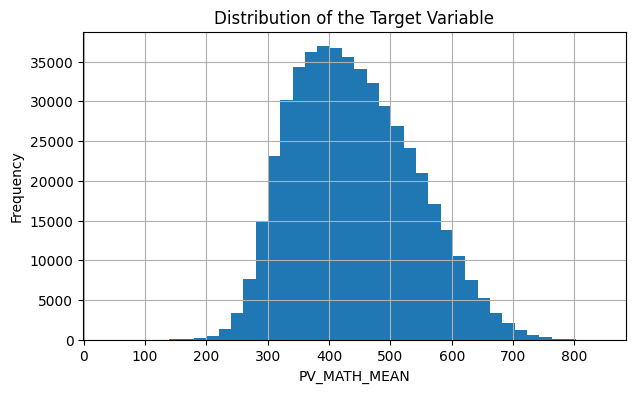

,correlation_with_target
PROGN,0.150943
COBN_F,-0.147918
COBN_M,-0.139508
LANGN,-0.125959
SUBNATIO,0.115614
VER_DAT,-0.098325
CNTRYID,0.095655
CNT,0.095655
COBN_S,-0.093590
STRATUM,0.092925


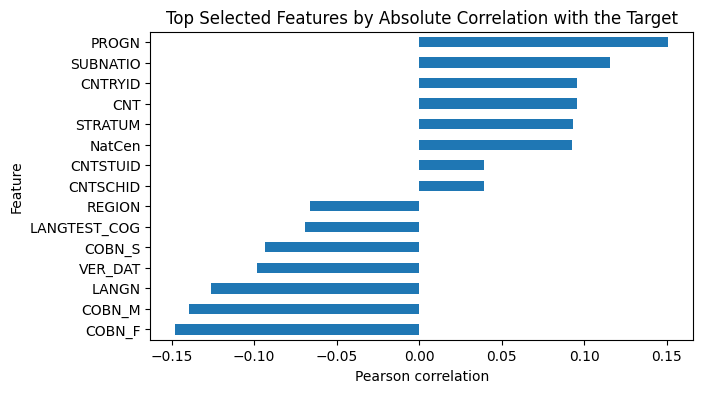

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

TARGET = 'PV_MATH_MEAN'
train_selected = pd.read_parquet('data/train_selected_features.parquet')
test_selected = pd.read_parquet('data/test_selected_features.parquet')

print('Training shape:', train_selected.shape)
print('Test shape:', test_selected.shape)
display(train_selected.describe().T)

plt.figure(figsize=(7, 4))
train_selected[TARGET].hist(bins=40)
plt.title('Distribution of the Target Variable')
plt.xlabel(TARGET)
plt.ylabel('Frequency')
plt.show()

corr = train_selected.corr(numeric_only=True)[TARGET].drop(TARGET).sort_values(key=lambda s: s.abs(), ascending=False)
display(corr.to_frame('correlation_with_target'))

plt.figure(figsize=(7, 4))
corr.head(15).sort_values().plot(kind='barh')
plt.title('Top Selected Features by Absolute Correlation with the Target')
plt.xlabel('Pearson correlation')
plt.ylabel('Feature')
plt.show()


The target variable exhibits an approximately normal distribution with sufficient variability for regression modeling. The correlation analysis shows that no individual feature has a strong linear relationship with `PV_MATH_MEAN` (since $|r| < 0.16$), suggesting that mathematical performance is influenced by multiple interacting factors rather than a single predictor. These findings support the use of non-linear models, such as Random Forest and Neural Networks, to capture more complex relationships within the data.

The selected features mainly represent demographic, geographic, linguistic, and institutional characteristics, including country, region, school, language, and socioeconomic indicators. Although each variable individually exhibits only a weak correlation with the target, together they capture complementary information that is likely to improve predictive performance. This supports the feature selection approach, as machine learning models can exploit complex interactions among these variables that are not evident through pairwise linear correlations alone.


## 6. t-SNE

A two-dimensional t-SNE projection is used as an exploratory visualization of the selected feature space. The points are colored according to the target value, allowing visual inspection of whether students with similar mathematics performance occupy nearby regions in the learned embedding. To keep the computation efficient, the visualization is based on a reproducible sample.

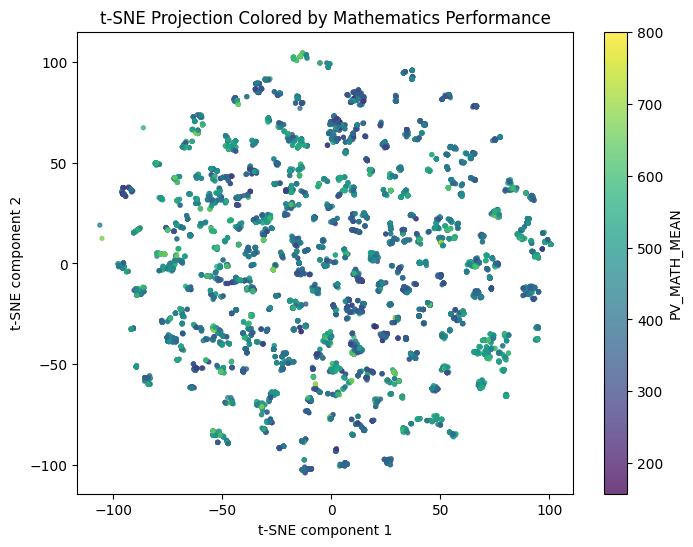

In [3]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import pandas as pd

TARGET = 'PV_MATH_MEAN'
TSNE_SAMPLE_SIZE = 10_000
RANDOM_STATE = 42

train_selected = pd.read_parquet('data/train_selected_features.parquet')
sample = train_selected.sample(min(TSNE_SAMPLE_SIZE, len(train_selected)), random_state=RANDOM_STATE)
X_tsne = SimpleImputer(strategy='median').fit_transform(sample.drop(columns=[TARGET]))
X_tsne = StandardScaler().fit_transform(X_tsne)

embedding = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', random_state=RANDOM_STATE).fit_transform(X_tsne)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=sample[TARGET], s=8, alpha=0.75)
plt.colorbar(scatter, label=TARGET)
plt.title('t-SNE Projection Colored by Mathematics Performance')
plt.xlabel('t-SNE component 1')
plt.ylabel('t-SNE component 2')
plt.show()


The t-SNE projection shows that the observations form several local clusters, but the target values are not clearly separated into distinct regions. Instead, low, medium, and high mathematics performance values appear partially mixed across the two-dimensional space. This suggests that the selected features contain some local structure, but the relationship with `PV_MATH_MEAN` is complex and not easily captured by a simple visual separation. Therefore, non-linear supervised models may still be useful, although strong class-like clustering should not be expected from these features alone.

## 7. Pipelines

Two supervised regression pipelines are evaluated: a Random Forest Regressor and a neural network implemented as a multilayer perceptron. Both pipelines include median imputation. The neural network pipeline also includes standardization because gradient-based models are sensitive to feature scale.

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

TARGET = 'PV_MATH_MEAN'
RANDOM_STATE = 42

train_selected = pd.read_parquet('data/train_selected_features.parquet')
test_selected = pd.read_parquet('data/test_selected_features.parquet')

X = train_selected.drop(columns=[TARGET])
y = train_selected[TARGET]
X_test = test_selected.drop(columns=[TARGET])
y_test = test_selected[TARGET]

X_train_model, X_valid_model, y_train_model, y_valid_model = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

rf_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), ('model', RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))])
nn_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('model', MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=250, early_stopping=True, random_state=RANDOM_STATE))])

In [2]:
from sklearn.metrics import root_mean_squared_error as rmse, mean_absolute_error, r2_score

def regression_metrics(model, X_eval, y_eval):
    pred = model.predict(X_eval)
    return {'RMSE': rmse(y_eval, pred), 'MAE': mean_absolute_error(y_eval, pred), 'R2': r2_score(y_eval, pred)}

baseline_results = []
for name, model in {'Random Forest': rf_pipeline, 'Neural Network': nn_pipeline}.items():
    model.fit(X_train_model, y_train_model)
    baseline_results.append({'model': name, **regression_metrics(model, X_valid_model, y_valid_model)})

display(pd.DataFrame(baseline_results).sort_values('RMSE'))

,model,RMSE,MAE,R2
0,Random Forest,72.060463,56.521425,0.462687
1,Neural Network,75.795248,60.338985,0.405548


## 8. Hyperparameter Optimization

Optuna is used to optimize one key hyperparameter for each model while minimizing cross-validated RMSE. The search is intentionally compact to keep execution time reasonable. If Optuna is unavailable, the notebook falls back to `RandomizedSearchCV`.

In [36]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

RANDOM_STATE = 42
target = "PV_MATH_MEAN"

OPTIMIZATION_SAMPLE_SIZE = 30_000
CV_FOLDS_OPTIMIZATION = 5

train_selected = pd.read_parquet("data/train_selected_features.parquet")
test_selected = pd.read_parquet("data/test_selected_features.parquet")

X_train = train_selected.drop(columns=[target])
y_train = train_selected[target]

if len(X_train) > OPTIMIZATION_SAMPLE_SIZE:
    opt_idx = X_train.sample(
        n=OPTIMIZATION_SAMPLE_SIZE,
        random_state=RANDOM_STATE
    ).index
    X_opt = X_train.loc[opt_idx]
    y_opt = y_train.loc[opt_idx]
else:
    X_opt = X_train
    y_opt = y_train

print(f"Optimization sample size: {X_opt.shape[0]:,} rows")
print(f"Number of features: {X_opt.shape[1]}")
print(f"Optimization CV: {CV_FOLDS_OPTIMIZATION}-fold")
print("Starting compact grid search optimization...\n")

rmse_scorer = make_scorer(
    lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
    greater_is_better=False
)

cv_opt = KFold(
    n_splits=CV_FOLDS_OPTIMIZATION,
    shuffle=True,
    random_state=RANDOM_STATE
)

rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

nn_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=8,
        max_iter=300,
        random_state=RANDOM_STATE
    ))
])

search_spaces = {
    "Random Forest": {
        "pipeline": rf_pipeline,
        "params": {
            # Main hyperparameter for the optimization plot
            "model__max_depth": [10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30],

            # Limited secondary hyperparameters to control runtime
            "model__n_estimators": [120],
            "model__min_samples_leaf": [20],
            "model__max_features": ["sqrt"]
        }
    },
    "Neural Network": {
        "pipeline": nn_pipeline,
        "params": {
            # Main hyperparameter for the optimization plot
            "model__alpha": [1e-4, 1e-2, 1e-1, 1e0, 1e+1, 1e+2],

            # Limited secondary hyperparameters to control runtime
            "model__hidden_layer_sizes": [(64, 64)],
            "model__learning_rate_init": [1e-3],
            "model__batch_size": [512]
        }
    }
}

optimization_results = {}
optimization_summary = []

for model_name, config in search_spaces.items():
    print("=" * 70)
    print(f"Optimizing: {model_name}")

    n_combinations = np.prod([len(values) for values in config["params"].values()])
    total_fits = n_combinations * CV_FOLDS_OPTIMIZATION

    print(f"Grid combinations: {n_combinations}")
    print(f"Total CV fits: {total_fits}")
    print("Running GridSearchCV...\n")

    start_time = time.time()

    search = GridSearchCV(
        estimator=config["pipeline"],
        param_grid=config["params"],
        scoring=rmse_scorer,
        cv=cv_opt,
        n_jobs=-1,
        return_train_score=True,
        verbose=2
    )

    search.fit(X_opt, y_opt)

    elapsed = time.time() - start_time
    best_rmse = -search.best_score_

    print(f"\nFinished {model_name}")
    print(f"Elapsed time: {elapsed / 60:.2f} minutes")
    print(f"Best CV RMSE: {best_rmse:.4f}")
    print(f"Best parameters: {search.best_params_}\n")

    cv_results = pd.DataFrame(search.cv_results_)
    cv_results["model_name"] = model_name
    cv_results["mean_train_rmse"] = -cv_results["mean_train_score"]
    cv_results["mean_cv_rmse"] = -cv_results["mean_test_score"]

    optimization_results[model_name] = {
        "search": search,
        "cv_results": cv_results,
        "best_estimator": search.best_estimator_,
        "best_params": search.best_params_,
        "best_cv_rmse": best_rmse
    }

    optimization_summary.append({
        "model": model_name,
        "best_cv_rmse": best_rmse,
        "elapsed_minutes": elapsed / 60,
        "grid_combinations": n_combinations,
        "total_cv_fits": total_fits,
        "best_params": search.best_params_
    })

optimization_summary = pd.DataFrame(optimization_summary).sort_values("best_cv_rmse")

optimization_cv_results = pd.concat(
    [result["cv_results"] for result in optimization_results.values()],
    ignore_index=True
)

best_model_name = optimization_summary.iloc[0]["model"]
best_model = optimization_results[best_model_name]["best_estimator"]
best_params = optimization_results[best_model_name]["best_params"]

best_rf_model = optimization_results["Random Forest"]["best_estimator"]
best_nn_model = optimization_results["Neural Network"]["best_estimator"]

print("=" * 70)
print("Optimization completed.")
print(f"Best model: {best_model_name}")
print(f"Best CV RMSE: {optimization_summary.iloc[0]['best_cv_rmse']:.4f}")
print(f"Best parameters: {best_params}")

display(optimization_summary)

Optimization sample size: 30,000 rows
Number of features: 15
Optimization CV: 5-fold
Starting compact grid search optimization...

Optimizing: Random Forest
Grid combinations: 11
Total CV fits: 55
Running GridSearchCV...

Fitting 5 folds for each of 11 candidates, totalling 55 fits

Finished Random Forest
Elapsed time: 0.33 minutes
Best CV RMSE: 75.1098
Best parameters: {'model__max_depth': 28, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 20, 'model__n_estimators': 120}

Optimizing: Neural Network
Grid combinations: 6
Total CV fits: 30
Running GridSearchCV...

Fitting 5 folds for each of 6 candidates, totalling 30 fits

Finished Neural Network
Elapsed time: 2.19 minutes
Best CV RMSE: 82.2280
Best parameters: {'model__alpha': 10.0, 'model__batch_size': 512, 'model__hidden_layer_sizes': (64, 64), 'model__learning_rate_init': 0.001}

Optimization completed.
Best model: Random Forest
Best CV RMSE: 75.1098
Best parameters: {'model__max_depth': 28, 'model__max_features': 'sqrt',

c:\Users\nicoc\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


,model,best_cv_rmse,elapsed_minutes,grid_combinations,total_cv_fits,best_params
0,Random Forest,75.109764,0.332991,11,55,"{'model__max_depth': 28, 'model__max_features'..."
1,Neural Network,82.227965,2.191776,6,30,"{'model__alpha': 10.0, 'model__batch_size': 51..."


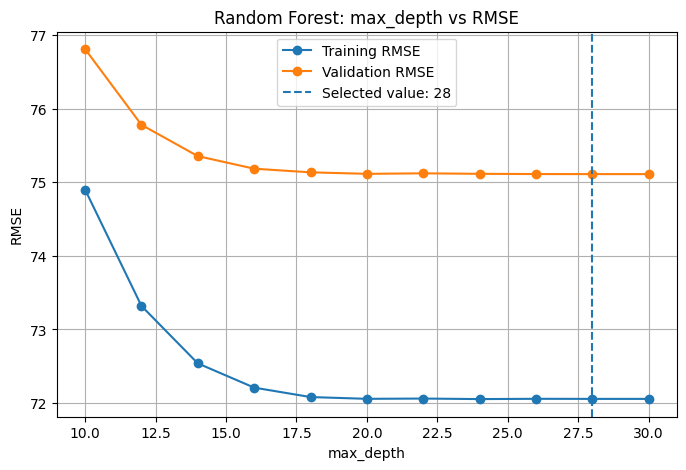

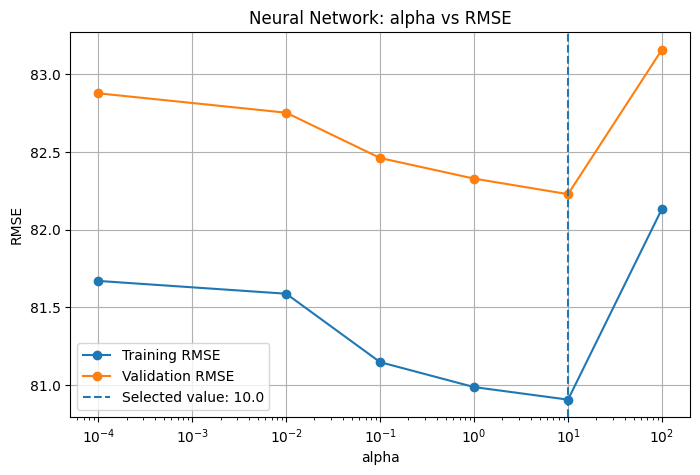

In [37]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_hyperparameter_vs_loss(model_name, hyperparameter, log_scale=False):
    param_col = f"param_model__{hyperparameter}"

    plot_df = optimization_cv_results[
        optimization_cv_results["model_name"] == model_name
    ].copy()

    if param_col not in plot_df.columns:
        raise ValueError(f"{param_col} was not found in optimization_cv_results.")

    # Average across secondary hyperparameters to isolate the effect of the selected one.
    plot_df = (
        plot_df
        .groupby(param_col, as_index=False)
        .agg(
            mean_train_rmse=("mean_train_rmse", "mean"),
            mean_cv_rmse=("mean_cv_rmse", "mean"),
            std_cv_rmse=("mean_cv_rmse", "std")
        )
        .sort_values(param_col)
    )

    best_value = optimization_results[model_name]["best_params"][f"model__{hyperparameter}"]

    plt.figure(figsize=(8, 5))

    plt.plot(
        plot_df[param_col],
        plot_df["mean_train_rmse"],
        marker="o",
        label="Training RMSE"
    )

    plt.plot(
        plot_df[param_col],
        plot_df["mean_cv_rmse"],
        marker="o",
        label="Validation RMSE"
    )

    plt.axvline(
        best_value,
        linestyle="--",
        label=f"Selected value: {best_value}"
    )

    if log_scale:
        plt.xscale("log")

    plt.title(f"{model_name}: {hyperparameter} vs RMSE")
    plt.xlabel(hyperparameter)
    plt.ylabel("RMSE")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_hyperparameter_vs_loss("Random Forest", "max_depth")
plot_hyperparameter_vs_loss("Neural Network", "alpha", log_scale=True)

In [45]:
# ============================================================
# Learning curves
# ============================================================
# These curves evaluate whether each optimized model benefits from additional
# training data. The models use the best hyperparameters found previously, so
# this step does not repeat hyperparameter optimization.

import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import learning_curve, KFold
from sklearn.metrics import mean_squared_error, make_scorer

RANDOM_STATE = 42
LEARNING_CURVE_SAMPLE_SIZE = 240_000
CV_FOLDS_LEARNING_CURVE = 3

X_train = train_selected.drop(columns=[target])
y_train = train_selected[target]

# Use a representative subsample to keep the learning curve computationally feasible.
if len(X_train) > LEARNING_CURVE_SAMPLE_SIZE:
    lc_idx = X_train.sample(
        n=LEARNING_CURVE_SAMPLE_SIZE,
        random_state=RANDOM_STATE
    ).index
    X_lc = X_train.loc[lc_idx]
    y_lc = y_train.loc[lc_idx]
else:
    X_lc = X_train
    y_lc = y_train

print(f"Learning curve sample size: {X_lc.shape[0]:,} rows")
print(f"Number of features: {X_lc.shape[1]}")
print(f"CV folds: {CV_FOLDS_LEARNING_CURVE}")
print("Starting learning curve computation...\n")

rmse_scorer = make_scorer(
    lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
    greater_is_better=False
)

cv_learning_curve = KFold(
    n_splits=CV_FOLDS_LEARNING_CURVE,
    shuffle=True,
    random_state=RANDOM_STATE
)

models_for_learning_curve = {
    "Random Forest": best_rf_model,
    "Neural Network": best_nn_model
}

learning_curve_results = {}

for model_name, model in models_for_learning_curve.items():
    print("=" * 70)
    print(f"Computing learning curve for: {model_name}")
    start_time = time.time()

    train_sizes, train_scores, cv_scores = learning_curve(
        estimator=clone(model),
        X=X_lc,
        y=y_lc,
        train_sizes=np.linspace(0.2, 1.0, 5),
        cv=cv_learning_curve,
        scoring=rmse_scorer,
        n_jobs=-1,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    train_rmse = -train_scores
    cv_rmse = -cv_scores

    learning_curve_results[model_name] = {
        "train_sizes": train_sizes,
        "train_rmse_mean": train_rmse.mean(axis=1),
        "train_rmse_std": train_rmse.std(axis=1),
        "cv_rmse_mean": cv_rmse.mean(axis=1),
        "cv_rmse_std": cv_rmse.std(axis=1)
    }

    elapsed = time.time() - start_time
    print(f"Finished {model_name}")
    print(f"Elapsed time: {elapsed / 60:.2f} minutes\n")

Learning curve sample size: 240,000 rows
Number of features: 15
CV folds: 3
Starting learning curve computation...

Computing learning curve for: Random Forest
Finished Random Forest
Elapsed time: 0.61 minutes

Computing learning curve for: Neural Network
Finished Neural Network
Elapsed time: 3.03 minutes



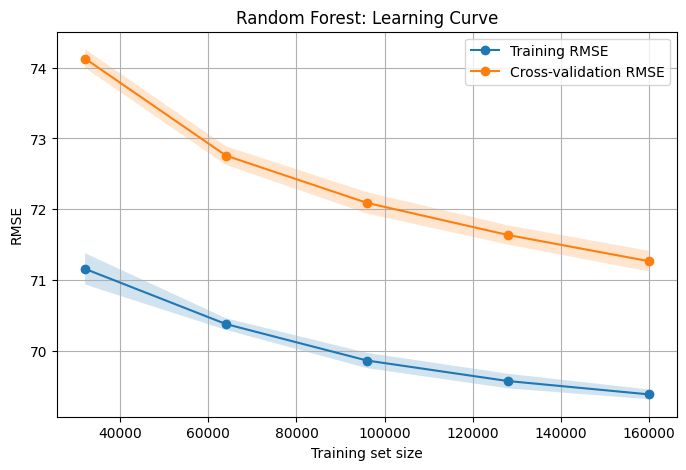

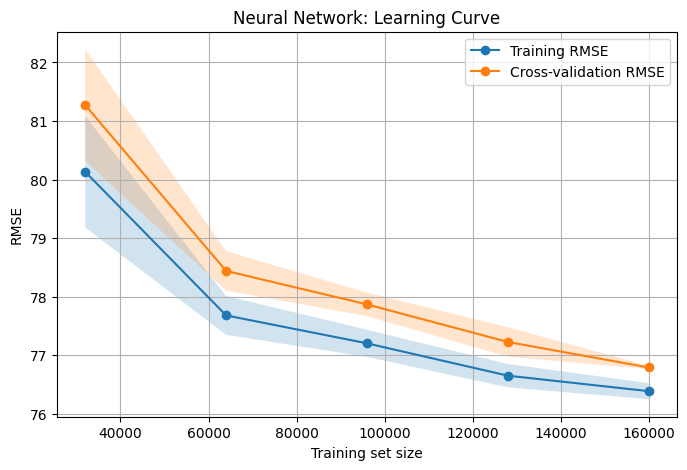

In [46]:
# ============================================================
# Plot learning curves
# ============================================================

def plot_learning_curve(model_name):
    results = learning_curve_results[model_name]

    train_sizes = results["train_sizes"]
    train_mean = results["train_rmse_mean"]
    train_std = results["train_rmse_std"]
    cv_mean = results["cv_rmse_mean"]
    cv_std = results["cv_rmse_std"]

    plt.figure(figsize=(8, 5))

    plt.plot(
        train_sizes,
        train_mean,
        marker="o",
        label="Training RMSE"
    )
    plt.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.2
    )

    plt.plot(
        train_sizes,
        cv_mean,
        marker="o",
        label="Cross-validation RMSE"
    )
    plt.fill_between(
        train_sizes,
        cv_mean - cv_std,
        cv_mean + cv_std,
        alpha=0.2
    )

    plt.title(f"{model_name}: Learning Curve")
    plt.xlabel("Training set size")
    plt.ylabel("RMSE")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_learning_curve("Random Forest")
plot_learning_curve("Neural Network")

# Referencias

[1] Organisation for Economic Co-operation and Development (OECD), *"Student Performance (PISA),"* OECD. [Online]. Available: https://www.oecd.org/en/topics/student-performance-pisa.html. [Accessed: Jun. 21, 2026].